# 🌟 COSMIC v0.0.1 - Compatibilidad Automática

**Este notebook ha sido actualizado para COSMIC v0.0.1**

## ✨ Mejoras Disponibles
- **Estructura modular**: `cosmic.core`, `cosmic.io`, `cosmic.preprocess`, `cosmic.analysis`
- **Imports modernos**: Específicos y organizados
- **API mejorada**: Mejor manejo de errores y configuración
- **Compatibilidad total**: El código existente sigue funcionando

## 🔄 Migración Opcional
Para usar las nuevas funcionalidades:
```python
# Nuevo (recomendado)
from cosmic.analysis.analyzer import ClusterAnalyzer
from cosmic.core.clustering import Clustering
from cosmic.io.loader import DataLoader

# Legacy (sigue funcionando)
from COSMIC import ClusterAnalyzer
from clustering import HDBSCANClustering
from data_loader import DataLoader
```

📚 **Documentación**: `/docs/reference/NOTEBOOK_MIGRATION_GUIDE.md`

# COSMIC v0.0.1 - Compatibilidad Automática

🔄 **Este notebook ha sido actualizado automáticamente para COSMIC v0.0.1**

- Estructura modular implementada
- Imports legacy mantienen compatibilidad  
- API mejorada disponible
- Sin cambios requeridos en código existente

Para usar las nuevas funcionalidades, consulta: `/docs/reference/NOTEBOOK_MIGRATION_GUIDE.md`

# COSMIC

## Modules

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import astropy.units as u
import matplotlib.ticker as ticker
import pymc as pm
import pymc.sampling_jax as pm_jax
import arviz as az
from astropy.table import QTable
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import quantity_support
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from astropy.coordinates import SkyCoord,angular_separation

%config InlineBackend.figure_format ='retina'
quantity_support();

## Data read

In [23]:
data_gaia = QTable(ascii.read('25_arcmin_clustered.ecsv', guess=False, format='ecsv'))

cluster_0 = (data_gaia['cluster'] == 0)
cluster_1 = (data_gaia['cluster'] == 1)
noise = (data_gaia['cluster'] == -1)

if len(data_gaia[cluster_0]) <= len(data_gaia[cluster_1]):
    raw_cluster = cluster_0
    noise_cluster = cluster_1
else:
    raw_cluster = cluster_1
    noise_cluster = cluster_0

probably_members = (raw_cluster & (data_gaia['probability'] < 0.8))
selected_cluster = (raw_cluster & (data_gaia['probability'] >= 0.8))

In [14]:
# Read the FITS file
with fits.open('NGC6383.fits') as hdulist:
    # Extract the data and header information
    data = hdulist[0].data
    header = hdulist[0].header
wcs = WCS(header);

 [astropy.io.fits.verify]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
Changed DATE-OBS from '1991/04/12' to '1991-04-12''. [astropy.wcs.wcs]


## Center determination

In [15]:
def center_determination(data, return_density=False, return_grids=False, return_bestparams=False):
    with warnings.catch_warnings():
        # Ignore warnings that may be raised during the execution
        warnings.filterwarnings("ignore")

        # Extract relevant data
        ra = data['ra_gaia']
        dec = data['dec_gaia']
        ra_err = data['ra_error']
        dec_err = data['dec_error']
        ra_dec = np.vstack([ra, dec]).T

        # Determine the bandwidth range for the grid search
        min_bandwidth = np.mean([np.mean(ra_err).to(u.deg).value, np.mean(dec_err).to(u.deg).value])
        params = {
            'bandwidth': np.linspace(min_bandwidth, 0.5, 500),
            'kernel': ['gaussian', 'epanechnikov', 'exponential', 'linear']
        }

        # Perform grid search to find the best kernel density estimator
        grid = GridSearchCV(KernelDensity(), params, cv=5, n_jobs=-1)
        grid.fit(ra_dec)
        kde = grid.best_estimator_

        # Create a grid for density estimation
        added_space_ra = (max(ra) - min(ra)) / 7
        added_space_dec = (max(dec) - min(dec)) / 7
        grid_ra, grid_dec = np.meshgrid(
            np.linspace(ra.min() - added_space_ra, ra.max() + added_space_ra, 700),
            np.linspace(dec.min() - added_space_dec, dec.max() + added_space_dec, 700)
        )
        grid_points = np.vstack([grid_ra.ravel(), grid_dec.ravel()]).T

        # Estimate the log density and find the coordinates of maximum density
        log_density = kde.score_samples(grid_points)
        density = np.exp(log_density).reshape(grid_ra.shape)
        max_density_idx = np.argmax(density)
        max_density_coords = (grid_ra.ravel()[max_density_idx], grid_dec.ravel()[max_density_idx])

        # Prepare the results dictionary
        results = {'center_coords': max_density_coords}
        if return_density:
            results['density'] = density
        if return_grids:
            results['grid_ra'] = grid_ra
            results['grid_dec'] = grid_dec
        if return_bestparams:
            results['best_params'] = grid.best_params_
            
        return results

In [39]:
def graph_center_determination(data, projection=None, savefig=None, prob_number=[60, 70, 80, 90]):
    subplot_kw = {'projection': projection}
    centers = []
    best_params_list = []
    prob_number = np.array(prob_number) / 100
    
    if len(prob_number) == 1:
        fig_kde, ax_kde = plt.subplots(1, layout='tight', figsize=(7,7), subplot_kw=subplot_kw)
    if len(prob_number) == 2:
        fig_kde, ax_kde = plt.subplots(1,2, layout='tight', figsize=(17.5,7), subplot_kw=subplot_kw)
    if len(prob_number) == 3:
        fig_kde, ax_kde = plt.subplots(1,3, layout='tight', figsize=(15,15), subplot_kw=subplot_kw)
    if len(prob_number) == 4:
        fig_kde, ax_kde = plt.subplots(2,2, layout='tight', figsize=(15,15), subplot_kw=subplot_kw)
    if projection == None:
        transform = None
    if len(prob_number) == 1:
        ax_kde = np.array(ax_kde)
    for i, ax in zip(prob_number, ax_kde.flatten()):
        print(f"{i * 100}%")
        
        selected_data = data[data['probability'] >= i]
        results = center_determination(selected_data, return_density=True, return_grids=True, return_bestparams=True)
        max_density_coords = results['center_coords']
        density = results['density']
        grid_ra = results['grid_ra']
        grid_dec = results['grid_dec']
        best_params = results['best_params']
        levels = np.linspace(density.min(), density.max(), 10)
        if projection is not None:
            ax.scatter(selected_data['ra_gaia'], selected_data['dec_gaia'], color='yellow', s=30, marker='*', transform=ax.get_transform('world'))
            ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue', transform=ax.get_transform('world'))
            ax.contour(grid_ra, grid_dec, density, levels=levels, cmap='viridis',transform=ax.get_transform('world'))
            coord = SkyCoord(ra=max_density_coords[0], dec=max_density_coords[1], frame='icrs', unit='deg')
            pixels = ax.wcs.world_to_pixel(coord)
            ax.axvline(pixels[0], color='lavender', ls='--')
            ax.axhline(pixels[1], color='lavender', ls='--')
            ax.coords.grid(True, color='gray', linestyle='dotted')
            #ax.coords[0].set_major_formatter('dd')
            #ax.coords[1].set_major_formatter('dd')
        if projection is None:
            ax.scatter(selected_data['ra_gaia'], selected_data['dec_gaia'], color='yellow', s=30, marker='*')
            ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue')
        ax.set(xlabel=r'$\alpha$ [{}]'.format(data['ra_gaia'].unit), ylabel=r'$\delta$ [{}]'.format(data['dec_gaia'].unit))
        lim_coord_min = SkyCoord(ra=grid_ra.min(), dec=grid_dec.min(), frame='icrs', unit='deg')
        lim_coord_max = SkyCoord(ra=grid_ra.max(), dec=grid_dec.max(), frame='icrs', unit='deg')
        pixels_min,pixels_max = ax.wcs.world_to_pixel(lim_coord_min),ax.wcs.world_to_pixel(lim_coord_max)
        ax.set_ylim(pixels_min[0],pixels_max[0])
        ax.set_xlim(pixels_min[1],pixels_max[1])
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in')
        ax.set_aspect('equal')
        ax.set_facecolor('black')
        ax.set_title(str(round(i * 100)) + '% probability members')
        # Legend
        legend_label = r'$C = ({:.4f},{:.4f})\;{}$'.format(max_density_coords[0].value, max_density_coords[1].value, u.deg)
        ax.legend([legend_label], loc='best', shadow=True, framealpha=0.8)
        
        best_params_list.append(best_params)
        centers.append(max_density_coords)
    if savefig:
        fig_kde.savefig(f"{savefig}center_determination.png", dpi=1000, bbox_inches='tight')
    return centers, best_params_list

70.0%


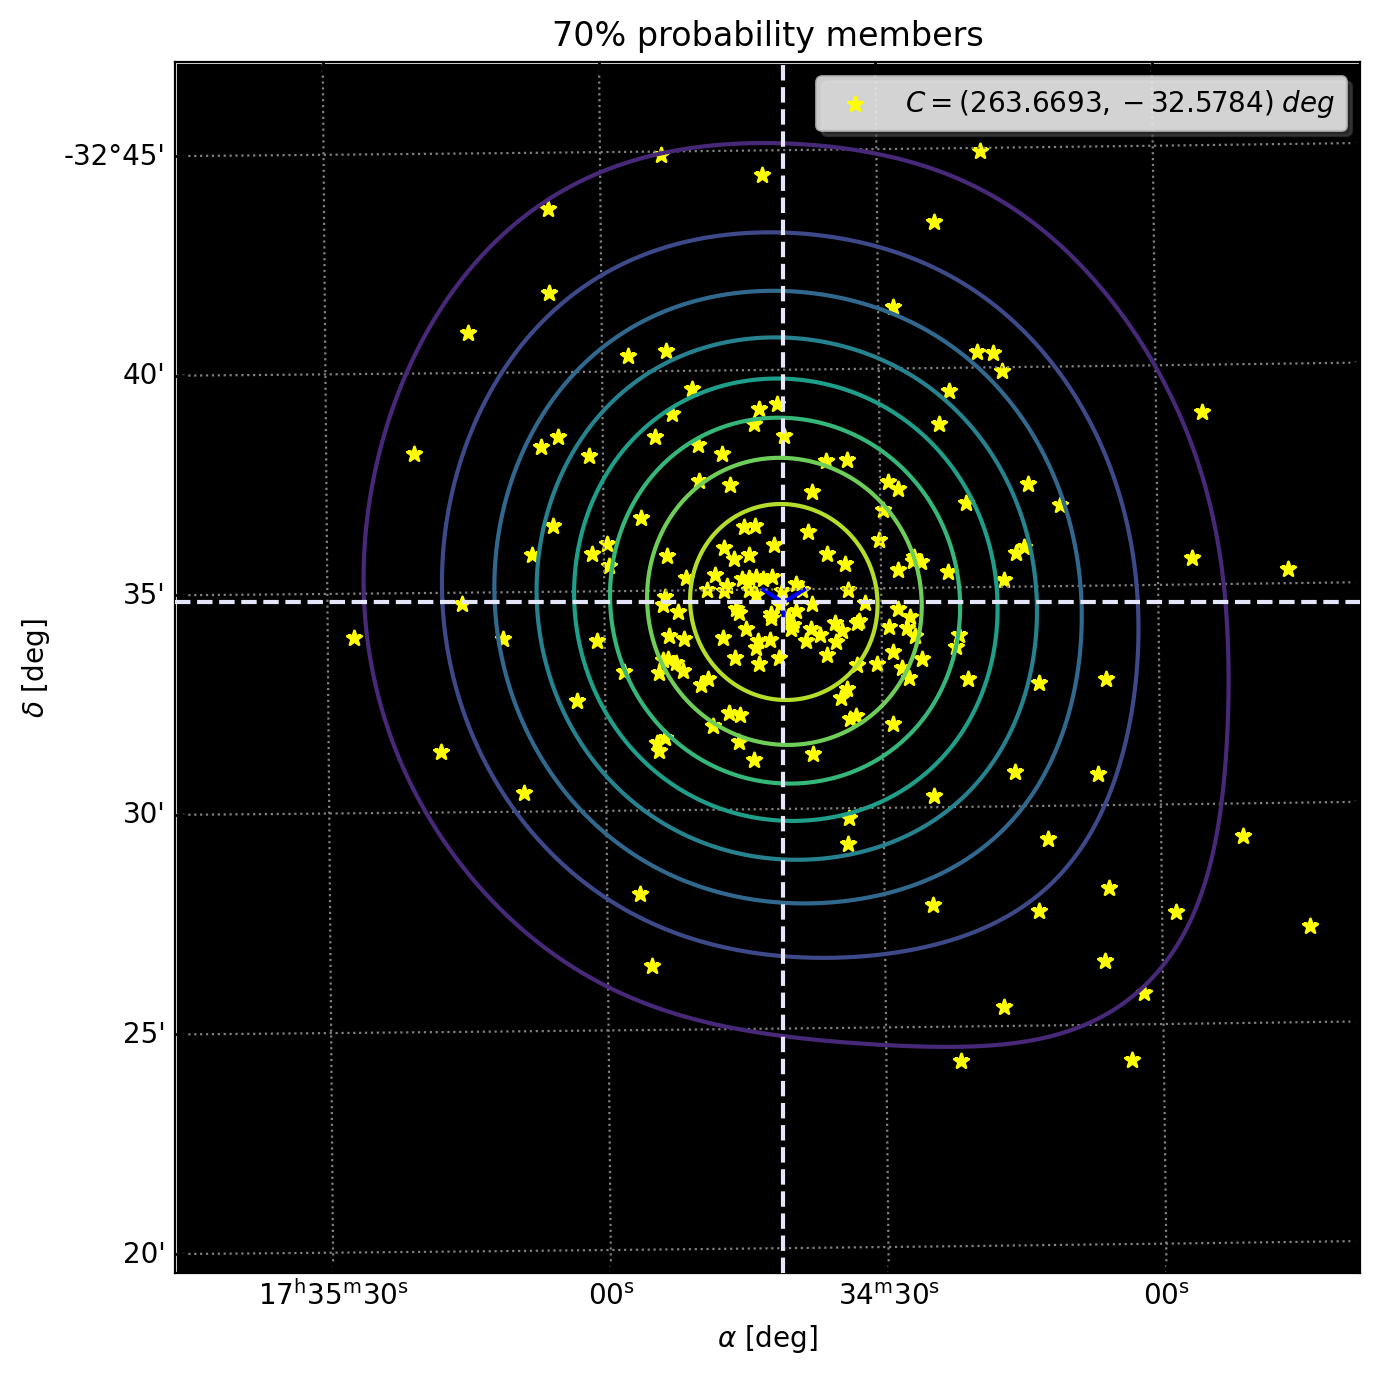

In [40]:
centers, params_list = graph_center_determination(data_gaia[raw_cluster],projection=wcs,savefig='Tex_File/Figures/',prob_number=[70])

## Radial density profile

3P King Porfile

$
f(R)  = k \left[\dfrac{1}{\sqrt{1+\left(\frac{R}{R_c}\right)^2}} - \dfrac{1}{\sqrt{1+\left(\frac{R_t}{R_c}\right)^2}}\right]^2+b
$

In [17]:
def density_annulus_calculator(data, center, width, return_radius_gen=False):
    d_center = (angular_separation(data['ra_gaia'], data['dec_gaia'], center.ra, center.dec)).to(u.arcmin)
    # Generate radii
    radius_gen = np.concatenate((np.arange(0, max(d_center.value) / 2, width),
                                 np.arange(max(d_center.value) / 2, 1.1 * max(d_center.value), 2 * width)))
    # Initialize lists to store density and density errors for annulus and circles
    density_annulus = []
    density_errors_annulus = []
    valid_radii = []  # List to store radii corresponding to non-zero densities

    # Calculate density using annulus
    for i in range(len(radius_gen) - 1):
        inner_radius = radius_gen[i]
        outer_radius = radius_gen[i + 1]
        criteria = (d_center >= inner_radius * u.arcmin) & (d_center < outer_radius * u.arcmin)
        counts = len(d_center[criteria])
        annulus_area = np.pi * (outer_radius ** 2 - inner_radius ** 2)
        if counts > 0:  # Only consider annuli with non-zero counts
            density_r_annulus = counts / annulus_area
            density_error_r_annulus = np.sqrt(counts) / annulus_area
            density_annulus.append(density_r_annulus)
            density_errors_annulus.append(density_error_r_annulus)
            valid_radii.append((inner_radius + outer_radius) / 2)  # Midpoint of the annulus

    results = {
        'density_annulus': density_annulus,
        'density_errors_annulus': density_errors_annulus
    }
    if return_radius_gen:
        results['radius_gen'] = valid_radii  # Return only the radii for non-zero densities
    return results

In [18]:
def RDP_bayesian(density_annulus, radius_gen, return_trace=False,progressbar=False):
    with pm.Model() as king_model:
        sigma = pm.Poisson('sigma', sigma=5)
        k = pm.TruncatedNormal('k', mu=5, sigma=5, lower=0)
        R_c = pm.TruncatedNormal('R_c', mu=2, sigma=5, lower=0)
        R_t = pm.TruncatedNormal('R_t', mu=20, sigma=5, lower=0)
        b = pm.Normal('b', mu=0, sigma=1)
        r = pm.ConstantData('radius', radius_gen)
        density_points = pm.ConstantData('density', density_annulus)

        king = pm.Deterministic('king', pm.math.switch(r < R_t,
                                                       k * ((1 / pm.math.sqrt(1 + (r / R_c) ** 2)) - (1 / pm.math.sqrt(1 + (R_t / R_c) ** 2))) ** 2 + b,
                                                       b))
        obs_density = pm.Normal('obs_density', mu=king, sigma=sigma, observed=density_points)
    rhat = [2, 2]
    target_accept = 0.8
    tune = 4000
    while any(x > 1 for x in rhat):
        with king_model:
            king_trace = pm_jax.sample_numpyro_nuts(draws=100000, tune=tune, target_accept=target_accept, random_seed=np.random.randint(1, 100000),progressbar=progressbar)
            rhat = az.summary(king_trace, var_names=["sigma", "k", "R_c", "R_t", "b"])['r_hat'].iloc[:]
        if target_accept <= 0.9999999:
            target_accept += 0.05
        tune += 2000

    k_mean = king_trace.posterior['k'].median().item()
    b_mean = king_trace.posterior['b'].median().item()
    R_c_mean = king_trace.posterior['R_c'].median().item()
    R_t_mean = king_trace.posterior['R_t'].median().item()
    k_std = king_trace.posterior['k'].std().item()
    b_std = king_trace.posterior['b'].std().item()
    R_c_std = king_trace.posterior['R_c'].std().item()
    R_t_std = king_trace.posterior['R_t'].std().item()
    king_std = king_trace.posterior['sigma'].median().item()

    results = {
        'k_mean': k_mean,
        'b_mean': b_mean,
        'R_c_mean': R_c_mean*u.arcmin,
        'R_t_mean': R_t_mean*u.arcmin,
        'k_std': k_std,
        'b_std': b_std,
        'R_c_std': R_c_std,
        'R_t_std': R_t_std,
        'king_std': king_std
    }
    if return_trace is True:
        results['king_trace'] = king_trace
    return results

In [19]:
def king_profile(x, k_mean, b_mean, R_c_mean, R_t_mean):
    king_profile = k_mean * ((1 / np.sqrt(1 + (x / R_c_mean)**2)) - 
                                  (1 / np.sqrt(1 + (R_t_mean / R_c_mean)**2)))**2 + b_mean
    return king_profile

In [43]:
def graph_king(data, centers, widths, savefig=None,return_trace=False,progressbar_bayesian=False,return_results=True,prob_number=[60,70,80,90]):
    # Assuming centers is a list of tuples or SkyCoord objects with ra & dec
    centers = [SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg') for ra, dec in centers]
    x_radius = np.arange(0, 30, 0.001)
    prob_number = np.array(prob_number) / 100
    if len(prob_number) == 1:
        fig_king, ax_king = plt.subplots(1, layout='tight', figsize=(7,7))
    if len(prob_number) == 2:
        fig_king, ax_king = plt.subplots(1,2, layout='tight', figsize=(17.5,7))
    if len(prob_number) == 3:
        fig_king, ax_king = plt.subplots(1,3, layout='tight', figsize=(15,15))
    if len(prob_number) == 4:
        fig_king, ax_king = plt.subplots(2,2, layout='tight', figsize=(15,15))
    if len(prob_number) == 1:
        ax_king = np.array(ax_king)
    all_bayesian_results = {
        'k_mean': [],
        'b_mean': [],
        'R_c_mean': [],
        'R_t_mean': [],
        'k_std': [],
        'b_std': [],
        'R_c_std': [],
        'R_t_std': [],
        'king_std': []
        }
    all_traces = []
    for i, ax, width, center in zip(prob_number, ax_king.flatten(), widths, centers):
        print(str(round(i * 100)) + '%')
        probability_selection = data['probability'] >= i
        iterative_data = data[probability_selection]
        # Calculate the density annulus (assumed function provided)
        density_results = density_annulus_calculator(iterative_data, center, width,return_radius_gen=True)
        # Perform Bayesian fitting (assumed function provided)
        bayesian_results = RDP_bayesian(density_results['density_annulus'], density_results['radius_gen'],return_trace=return_trace,progressbar=progressbar_bayesian)
        # Generate the king profile (assumed function provided)
        kp = king_profile(x_radius[x_radius < bayesian_results['R_t_mean'].value], 
                          bayesian_results['k_mean'], bayesian_results['b_mean'], 
                          bayesian_results['R_c_mean'].value, bayesian_results['R_t_mean'].value)

        # Plotting the king profile and the observed data points
        ax.plot(x_radius[x_radius < bayesian_results['R_t_mean'].value], kp, label='King Model 3P', color='fuchsia', alpha=0.7)
        ax.scatter(density_results['radius_gen'], density_results['density_annulus'], s=6, label='RDP annulus', color='blue')
        ax.errorbar(density_results['radius_gen'], density_results['density_annulus'], 
                    yerr=density_results['density_errors_annulus'], fmt='none', ecolor='k', alpha=0.3)
        # Adding vertical lines for core and tidal radii, and horizontal line for background level
        ax.axvline(bayesian_results['R_c_mean'], color='red', label=r'$R_c = {:.3f}\,[{}]$'.format(bayesian_results['R_c_mean'].value, u.arcmin), linestyle='--', linewidth=1.3)
        ax.axvline(bayesian_results['R_t_mean'], color='red', label=r'$R_t = {:.3f} \,[{}]$'.format(bayesian_results['R_t_mean'].value, u.arcmin), linestyle='dotted')
        ax.axhline(bayesian_results['b_mean'], color='green', alpha=0.8, linewidth=1, linestyle='--')
        y_min, y_max = ax.get_ylim()
        # Plotting the standard deviation as a filled area
        ax.fill_between(x_radius[x_radius < bayesian_results['R_t_mean'].value], 
                    kp - bayesian_results['king_std'],
                    kp + bayesian_results['king_std'], alpha=0.2, color='blue')
        # Plotting error regions for core and tidal radii using fill_betweenx
        ax.fill_betweenx([y_min, y_max], 
                     bayesian_results['R_c_mean'].value - bayesian_results['R_c_std'], 
                     bayesian_results['R_c_mean'].value + bayesian_results['R_c_std'], color='red', alpha=0.1)
        ax.fill_betweenx([y_min, y_max], 
                     bayesian_results['R_t_mean'].value - bayesian_results['R_t_std'], 
                     bayesian_results['R_t_mean'].value + bayesian_results['R_t_std'], color='red', alpha=0.1)
        # Setting labels, limits, and other plot attributes
        ax.set(xlabel=r'$r$ [{}]'.format(u.arcmin), ylabel=r'$\rho\, \left[stars\,/ \,arcmin^{2}\right]$')
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in')
        ax.set_title(str(round(i * 100)) + '% probability members')
        ax.legend()

        for key in all_bayesian_results.keys():
            all_bayesian_results[key].append(bayesian_results[key])
        # Store traces if requested
        if return_trace:
            all_traces.append(bayesian_results['king_trace'])
    # Save the figure if a save path is provided
    if savefig:
        plt.savefig(savefig + 'king_profile.png', dpi=800, bbox_inches='tight')
    # Return the collected results and/or traces if requested
    return_data = {}
    if return_results:
        return_data['bayesian_results'] = all_bayesian_results
    if return_trace:
        return_data['traces'] = all_traces
    plt.show()
    return return_data if return_data else None

Compiling...


70%


Compilation time = 0:00:01.080139
Sampling...
Sampling time = 0:00:03.513578
Transforming variables...
Transformation time = 0:00:00.444040


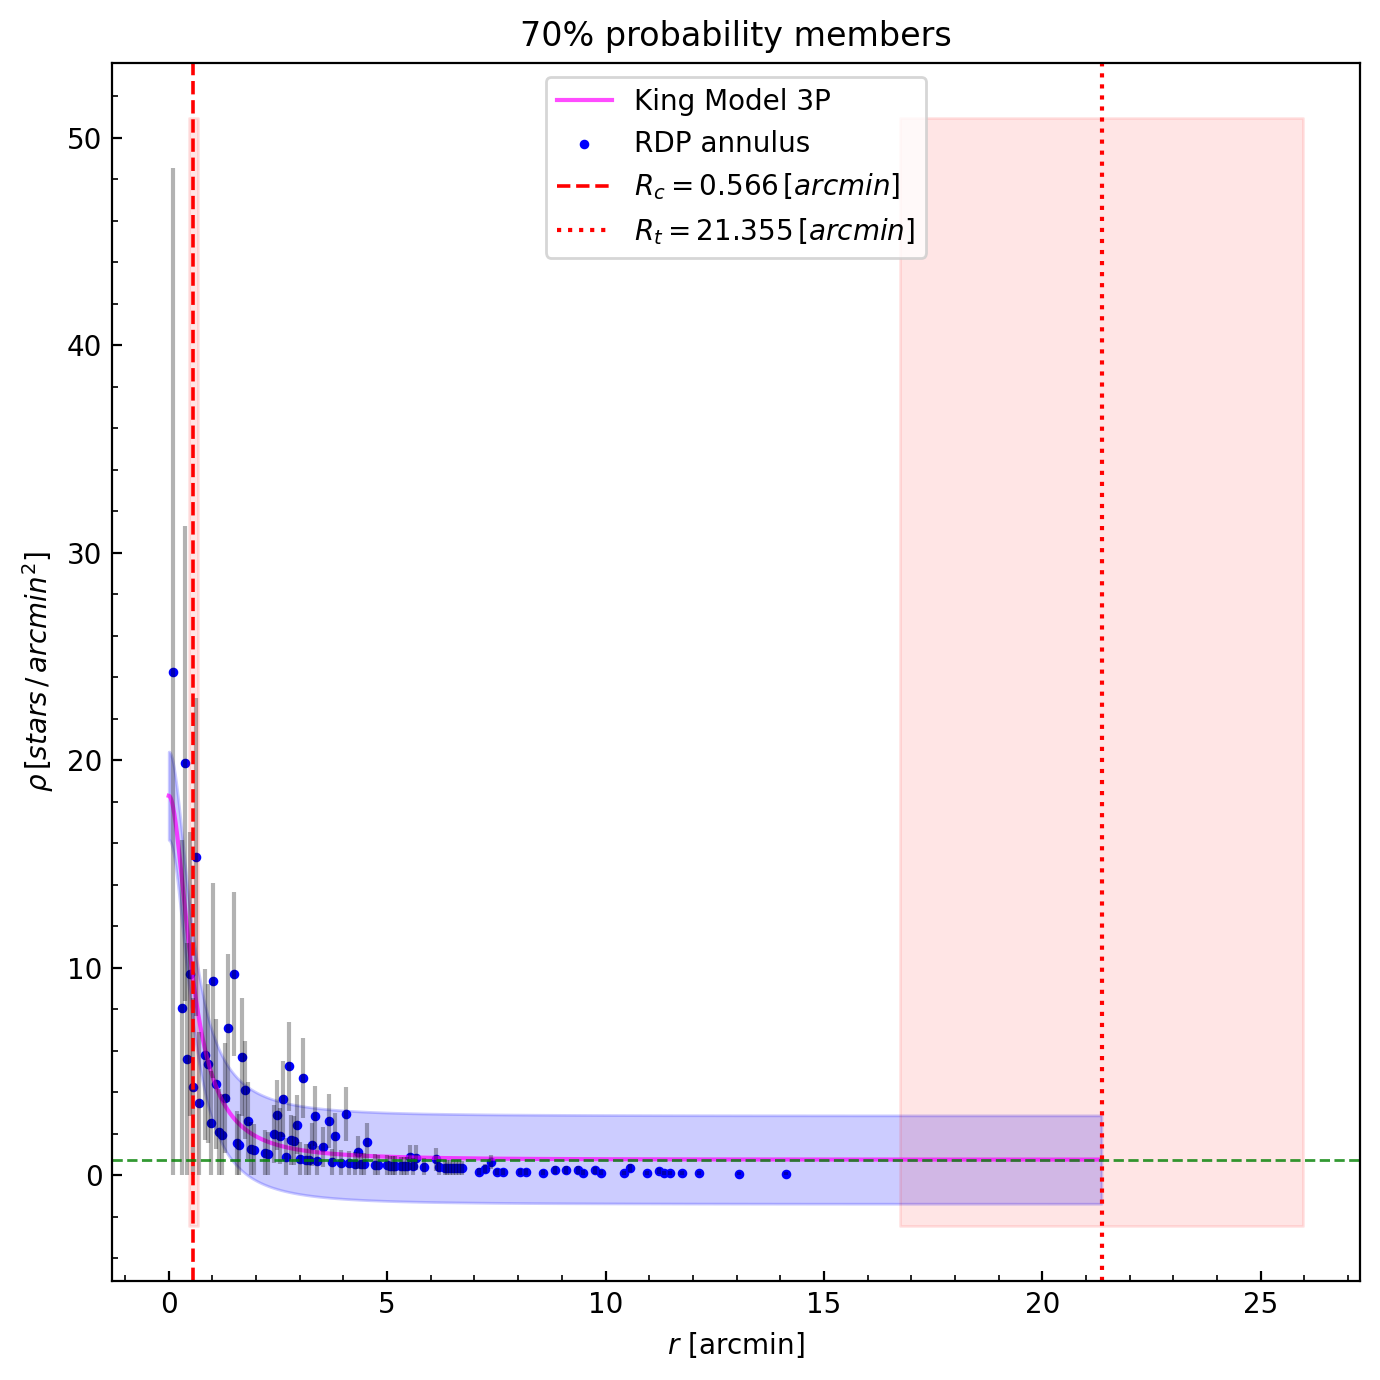

In [44]:
bandwidths = [params['bandwidth'] for params in params_list]
king_results = graph_king(data_gaia[raw_cluster],centers,bandwidths,return_trace=True,savefig='Tex_File/Figures/',prob_number=[70])

## Parallax

In [ ]:
def obtain_parallax(data):
    dist_var = 1 / (data["parallax_error"] ** 2)
    est_mean_plx = np.sum(data["parallax_corrected"] * dist_var) / np.sum(dist_var)
    est_mean_r = est_mean_plx.to_value(u.kpc, u.parallax())
    with pm.Model(check_bounds=True) as parallax_model:
        sigma = pm.HalfNormal('sigma', sigma=data[selected_cluster]['parallax_error'].std())
        mu = pm.TruncatedNormal("mu_d", mu=est_mean_r, sigma=sigma, lower=0)
        d = pm.TruncatedNormal("d", mu=mu, sigma=sigma, shape=len(data['parallax_corrected']), lower=0)
        parallax = pm.Deterministic('parallax', 1/d)
        observed = pm.ConstantData('parallax_observed',data['parallax_corrected'])
        pm.Normal("plx",mu=parallax,observed=observed,sigma=data['parallax_error']);
        rhat = 2
        target_accept = 0.8
        tune = 4000
        while rhat > 1.0:
            with parallax_model:
                parallax_trace = pm_jax.sample_numpyro_nuts(draws=100000, tune=tune,target_accept=target_accept, random_seed=np.random.randint(1, 100000))
                rhat = az.summary(parallax_trace, var_names=["mu_d"]).iloc[0]["r_hat"]
            if target_accept <= 0.9999999:
                target_accept += 0.05    
            tune += 2000

In [ ]:
# Histogram of parallax NGC6383

parallax_data_cluster = data_gaia['parallax_corrected'][selected_cluster]
par_data = np.arange(min(parallax_data_cluster).value, max(parallax_data_cluster).value,0.001)

fig_par, ax_par = plt.subplots(1,3, figsize=(22,7),layout='constrained',gridspec_kw={'width_ratios' : [1,1,1]})
ax_par[0].hist(parallax_data_cluster, bins='auto', histtype='step', density=True,hatch='//',color='orange',label='Parallax')
az.plot_dist(parallax_trace.constant_data['parallax_observed'],ax=ax_par[0],color='violet',kind='auto',label='Parallax KDE')
ax_par[0].axvline(bay_par_mean, color='b', linestyle='--', label=r'$\mu_\varpi = {:.4f}\,\pm {:.3f} [{}]$'.format(bay_par_mean,bay_par_sigma,u.mas))
ax_par[0].axvline(HD159176['parallax_corrected'], color='green', linestyle=(0, (3, 5, 1, 5)), label='HD 159176',linewidth=2)
ax_par[0].fill_betweenx([0,6],bay_par_mean.data - bay_par_sigma.data, bay_par_mean.data + bay_par_sigma.data,color='blue',alpha=0.04)
ax_par[0].set(xlabel=r'$\varpi$ [{}]'.format(data_gaia['parallax_corrected'].unit),ylabel='Density')
ax_par[0].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_par[0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_par[0].tick_params(axis='both', which='both', direction='in')
ax_par[0].legend()

ax_par[1].hist(1/parallax_trace.constant_data['parallax_observed'], bins='auto', histtype='step', density=True,hatch='//',color='orange',label='Parallax')
az.plot_dist(1/parallax_trace.constant_data['parallax_observed'],ax=ax_par[1],color='violet',kind='auto',label='Distance KDE')
ax_par[1].axvline(bay_dist_mean, color='b', linestyle='--', label=r'$d = {:.4f}\,\pm {:.3f} \,[{}]$'.format(bay_dist_mean,bay_dist_sigma,u.kpc))
ax_par[1].axvline(1/HD159176['parallax_corrected'], color='green', linestyle=(0, (3, 5, 1, 5)), label='HD 159176',linewidth=2)
ax_par[1].fill_betweenx([0,6],bay_dist_mean.data - bay_dist_sigma.data, bay_dist_mean.data + bay_dist_sigma.data,color='blue',alpha=0.04)
ax_par[1].set(xlabel=r'$d$ [{}]'.format(u.kpc),ylabel='Density')
ax_par[1].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_par[0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_par[1].tick_params(axis='both', which='both', direction='in')
ax_par[1].legend()

sc_par = ax_par[2].scatter(data_gaia[selected_cluster]['parallax_corrected'],data_gaia[selected_cluster]['Gmag'],c=data_gaia[selected_cluster]['probability'],alpha=0.9,cmap=sns.color_palette("flare", as_cmap=True),label='Sources')
ax_par[2].errorbar(data_gaia[selected_cluster]['parallax_corrected'], data_gaia[selected_cluster]['Gmag'], xerr=data_gaia['parallax_error'][selected_cluster], fmt='none', ecolor='k', alpha=0.1)
ax_par[2].axvline(bay_par_mean, color='m', linestyle='--', label=r'$\mu_\varpi = {:.4f}\,[{}]$'.format(bay_par_mean, u.mas))
ax_par[2].set(xlabel=r'$\varpi$ [{}]'.format(data_gaia['parallax_corrected'].unit),ylabel=r'$G_{{mag}}\,[{}]$'.format(data_gaia['Gmag'].unit))
ax_par[2].errorbar(HD159176['parallax_corrected'],HD159176['Gmag'],xerr=HD159176['parallax_error'],color='green',alpha=0.8)
ax_par[2].scatter(HD159176['parallax_corrected'],HD159176['Gmag'],label='HD 159176',color='green',marker='*',s=90)
ax_par[2].fill_betweenx([5,20],bay_par_mean.data - bay_par_sigma.data, bay_par_mean.data + bay_par_sigma.data,color='blue',alpha=0.04)
ax_par[2].legend()
ax_par[2].invert_yaxis(),ax_par[1].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_par[1].yaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_par[1].tick_params(axis='both', which='both', direction='in')
fig_par.colorbar(sc_par,orientation='vertical').set_label('Probabilities');

# Saving the figure
fig_par.savefig('Tex_File/Figures/ngc6383_parallax_distance.pdf',dpi=1000,bbox_inches='tight');

## Proper motion

In [ ]:
coords = {"axis": ["pmra", "pmdec"], "axis_bis" : ["pmra","pmdec"], "obs_id": data_gaia['solution_id'][selected_cluster]} 
with pm.Model(coords=coords) as model_pm:
    chol, corr, stds = pm.LKJCholeskyCov('chol', n=2, eta=2.0, sd_dist=pm.Exponential.dist(1.0, shape=2))
    cov = pm.Deterministic("cov", chol.dot(chol.T), dims=("axis", "axis_bis"))
    mu = pm.Normal("mu", mu=0, sigma=stds, dims='axis')
    pm_observed = pm.ConstantData('pm_observed',np.array([data_gaia['pmra_corr'][selected_cluster], data_gaia['pmdec_corr'][selected_cluster]]).T)
    obs = pm.MvNormal('obs', mu=mu, chol=chol, observed=pm_observed,dims=("obs_id", "axis"))
    pm_trace = pm_jax.sample_numpyro_nuts(draws=1000000, tune=200000, random_seed=np.random.randint(1, 100000),target_accept=0.99999,idata_kwargs={"dims": {"chol_stds": ["axis"], "chol_corr": ["axis", "axis_bis"]}})

In [ ]:
az.summary(pm_trace)